In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [18]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep Learning/EXP01/hrsst.csv')
X = dataset1[['Hours_Studied']].values
y = dataset1[['Marks']].values

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [20]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [22]:
# Name: Krishna Prasad S
# Register Number: 212223230108
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1,8)
        self.fc2 = nn.Linear(8,10)
        self.fc3 = nn.Linear(10,1)
        self.relu = nn.ReLU()
        self.history = {'loss': []}
  def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [23]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
l_bin = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(l_bin.parameters(), lr=0.001)

In [24]:
# Name: Krishna Prasad S
# Register Number: 212223230108
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(ai_brain(X_train), y_train)
        loss.backward()
        optimizer.step()
        l_bin.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [25]:
train_model(l_bin, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 4911.951172
Epoch [200/2000], Loss: 4357.287598
Epoch [400/2000], Loss: 3105.259766
Epoch [600/2000], Loss: 1572.346680
Epoch [800/2000], Loss: 416.703888
Epoch [1000/2000], Loss: 69.458984
Epoch [1200/2000], Loss: 56.081436
Epoch [1400/2000], Loss: 50.609303
Epoch [1600/2000], Loss: 47.396973
Epoch [1800/2000], Loss: 47.086548


In [26]:
with torch.no_grad():
    test_loss = criterion(l_bin(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 278.813019


In [27]:
loss_df = pd.DataFrame(l_bin.history)

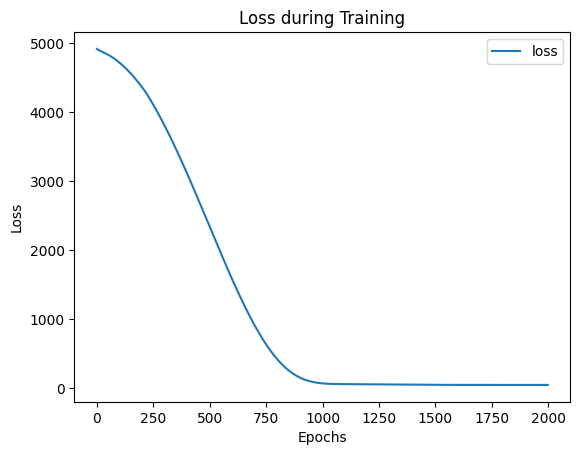

In [28]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [29]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = l_bin(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 91.98175048828125
